# Gráficos

In [8]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sys.path.append("..")
from src.utils import LIMPOS, COR_MUSICA, COR_FILME, COR_NEUTRA, estilo, salvar

estilo()

musicas = pd.read_csv(LIMPOS / "musicas_limpas.csv")
musicas_unicas = musicas.drop_duplicates(subset="id_musica")
filmes = pd.read_csv(LIMPOS / "filmes_limpos.csv")
filmes_generos = pd.read_csv(LIMPOS / "filmes_generos.csv")
por_ano = pd.read_csv(LIMPOS / "musicas_filmes_por_ano.csv")

conf = filmes[filmes["nota_confiavel"]]

GENEROS_FILME = {
    "Documentary": "Documentário", "History": "História", "Music": "Música", "War": "Guerra",
    "Animation": "Animação", "Drama": "Drama", "Western": "Faroeste", "Romance": "Romance",
    "Family": "Família", "Crime": "Crime", "Fantasy": "Fantasia", "TV Movie": "Filme de TV",
    "Adventure": "Aventura", "Mystery": "Mistério", "Comedy": "Comédia", "Action": "Ação",
    "Science Fiction": "Ficção científica", "Thriller": "Suspense", "Horror": "Terror",
}

## 1. Quais gêneros de playlist têm as músicas mais populares?

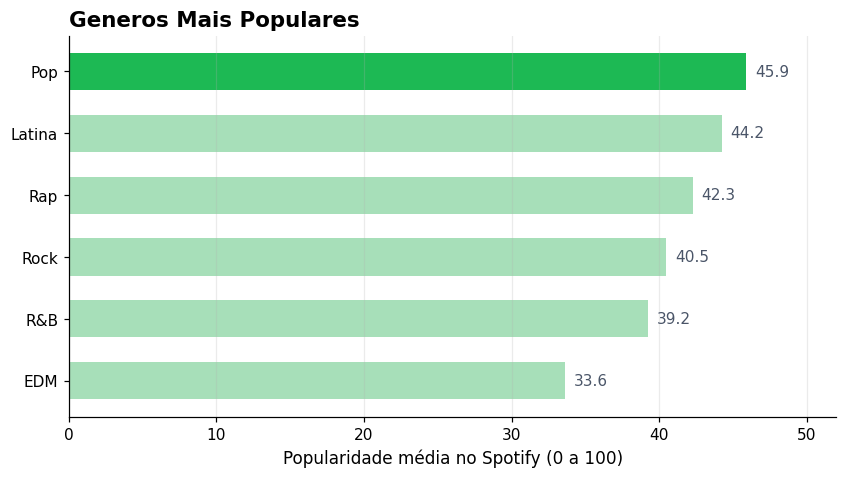

In [9]:
g1 = (musicas.drop_duplicates(subset=["id_musica", "genero_playlist"])
             .groupby("genero_playlist")["popularidade_musica"].mean()
             .sort_values())

fig, ax = plt.subplots(figsize=(9, 4.5))
cores = [COR_MUSICA if g == g1.idxmax() else "#A7DFB9" for g in g1.index]
ax.barh(g1.index, g1.values, color=cores, height=0.6)
for y, v in enumerate(g1.values):
    ax.text(v + 0.6, y, f"{v:.1f}", va="center", color=COR_NEUTRA)
ax.set_title("Generos Mais Populares")
ax.set_xlabel("Popularidade média no Spotify (0 a 100)")
ax.set_xlim(0, 52)
ax.grid(axis="y", visible=False)
salvar(fig, "01_popularidade_por_genero")
plt.show()

**Conclusão:** músicas de playlists de Pop têm popularidade média de 45,9, mais de 12 pontos acima das de EDM (33,6). Pop, Latina e Rap formam o grupo de cima.

## 2. A popularidade muda conforme o ano de lançamento?

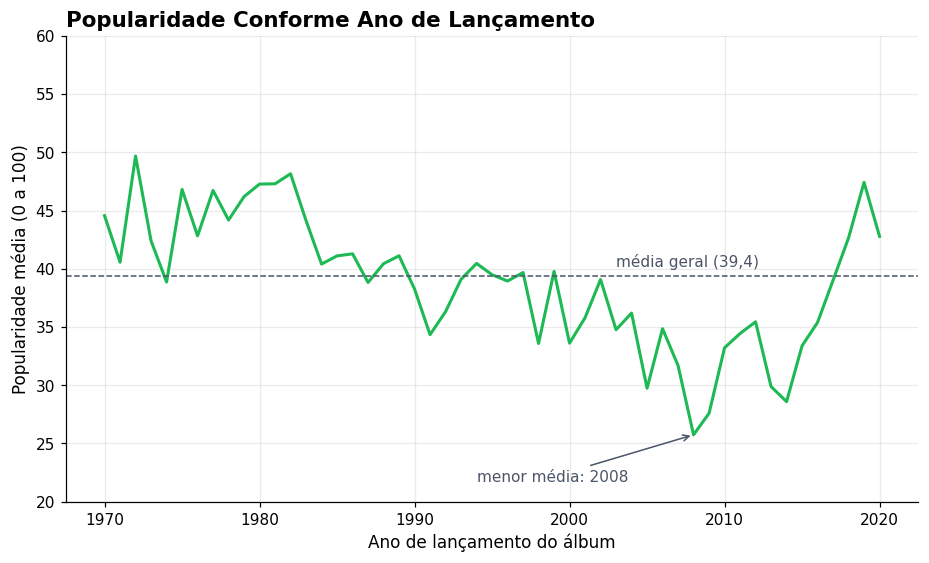

In [10]:
g2 = (musicas_unicas[musicas_unicas["ano_lancamento"] >= 1970]
      .groupby("ano_lancamento")["popularidade_musica"].agg(["mean", "count"]))
g2 = g2[g2["count"] >= 20]   # anos com poucas músicas geram médias instáveis

fig, ax = plt.subplots()
ax.plot(g2.index, g2["mean"], color=COR_MUSICA, linewidth=2)
ax.axhline(musicas_unicas["popularidade_musica"].mean(), color=COR_NEUTRA, linestyle="--", linewidth=1)
ax.text(2003, musicas_unicas["popularidade_musica"].mean() + 0.8, "média geral (39,4)", color=COR_NEUTRA)
vale = g2["mean"].idxmin()
ax.annotate(f"menor média: {vale}", xy=(vale, g2.loc[vale, "mean"]),
            xytext=(vale - 14, g2.loc[vale, "mean"] - 4),
            arrowprops=dict(arrowstyle="->", color=COR_NEUTRA), color=COR_NEUTRA)
ax.set_title("Popularidade Conforme Ano de Lançamento")
ax.set_xlabel("Ano de lançamento do álbum")
ax.set_ylabel("Popularidade média (0 a 100)")
ax.set_ylim(20, 60)
salvar(fig, "02_popularidade_por_ano")
plt.show()

**Conclusão:** a curva tem forma de "U". Músicas dos anos 70 e as mais recentes ficam acima da média geral, enquanto as dos anos 2000 ficam bem abaixo. Só entram anos com pelo menos 20 músicas.

## 3. Características do áudio têm relação com a popularidade? (seaborn)

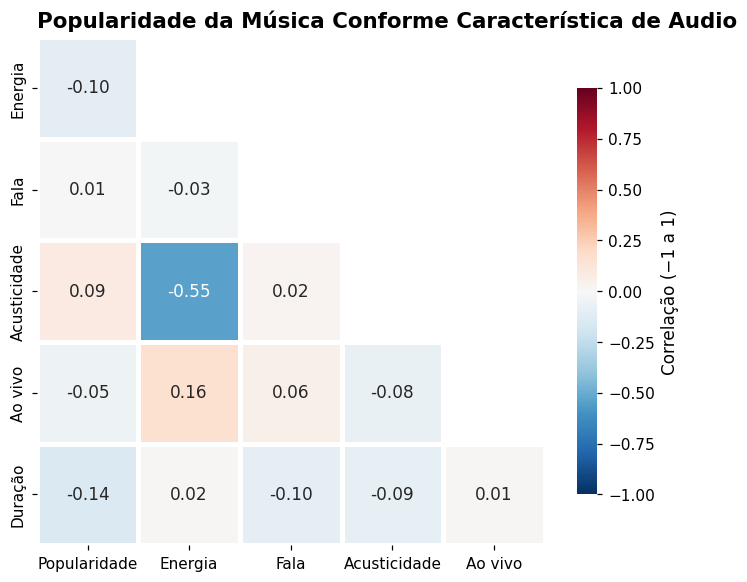

In [11]:
nomes = {"popularidade_musica": "Popularidade", "energia": "Energia", "fala": "Fala",
         "acusticidade": "Acusticidade", "prob_aovivo": "Ao vivo", "duracao_min": "Duração"}
corr = musicas_unicas[list(nomes)].rename(columns=nomes).corr()
corr = corr.iloc[1:, :-1]
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, mask=mascara, annot=True, annot_kws={"size": 11}, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, linewidths=2, linecolor="white", square=True,
            cbar_kws={"label": "Correlação (−1 a 1)", "shrink": 0.8}, ax=ax)
ax.set_title("Popularidade da Música Conforme Característica de Audio")
ax.grid(False)
salvar(fig, "03_correlacao_audio_popularidade")
plt.show()

**Conclusão:** todas as correlações com a popularidade ficam perto de zero (entre −0,14 e 0,09). A relação mais forte do mapa não envolve popularidade: músicas com mais **energia** tendem a ser menos **acústicas**.

## 4. As músicas ficaram mais curtas ao longo das décadas? (seaborn)

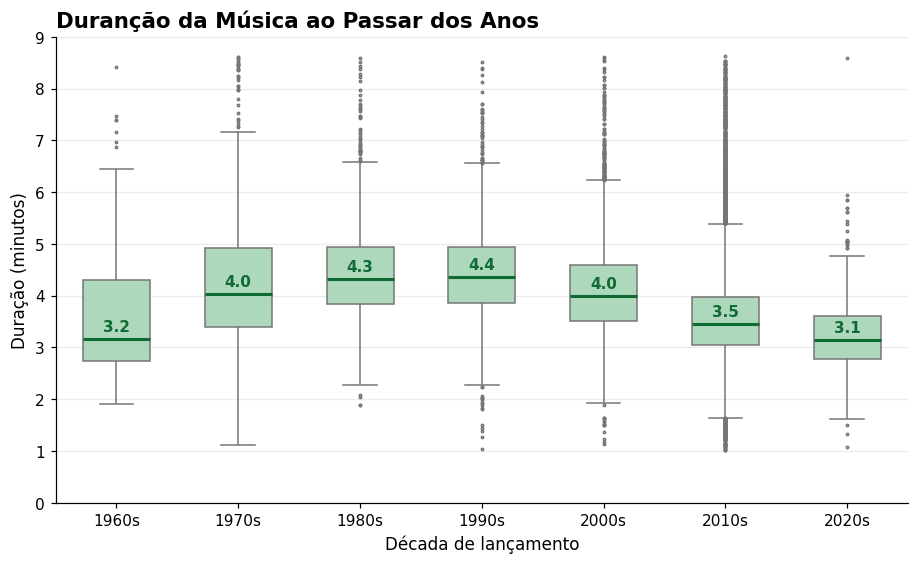

In [12]:
g4 = musicas_unicas[musicas_unicas["decada"] >= 1960].copy()
g4["decada_txt"] = g4["decada"].astype(str) + "s"
ordem = sorted(g4["decada_txt"].unique())

fig, ax = plt.subplots()
sns.boxplot(data=g4, x="decada_txt", y="duracao_min", order=ordem, color="#A7DFB9",
            width=0.55, fliersize=1.5, linewidth=1, ax=ax,
            medianprops=dict(color="#0F6B33", linewidth=2))
medianas = g4.groupby("decada_txt")["duracao_min"].median()
for i, d in enumerate(ordem):
    ax.text(i, medianas[d] + 0.15, f"{medianas[d]:.1f}", ha="center", color="#0F6B33", fontweight="bold")
ax.set_title("Duranção da Música ao Passar dos Anos")
ax.set_xlabel("Década de lançamento")
ax.set_ylabel("Duração (minutos)")
ax.set_ylim(0, 9)
salvar(fig, "04_duracao_por_decada")
plt.show()

**Conclusão:** a duração mediana subiu até os anos 80 e 90 (cerca de 4,3 min) e caiu para cerca de 3,1 min nos anos 2020. A caixa também ficou mais estreita: as músicas recentes têm durações mais parecidas entre si.

## 5. Quais gêneros de filme têm as maiores notas médias?

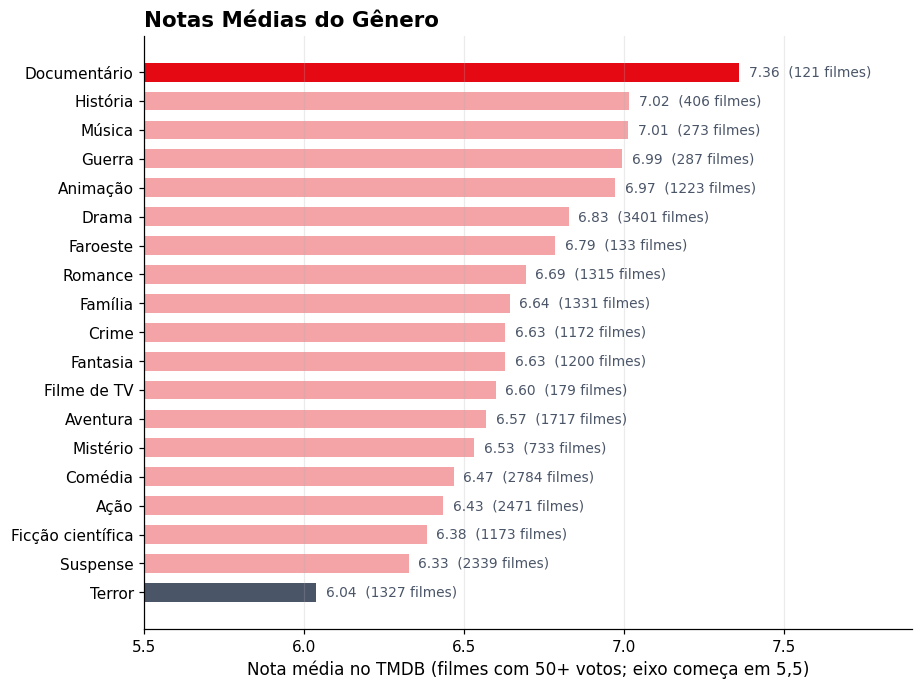

In [13]:
g5 = (filmes_generos[filmes_generos["nota_confiavel"]]
      .groupby("genero")["nota_media"].agg(["mean", "count"])
      .sort_values("mean"))
g5.index = g5.index.map(GENEROS_FILME)

fig, ax = plt.subplots(figsize=(9, 7))
cores = ["#F4A3A7"] * len(g5)
cores[-1] = COR_FILME
cores[0] = COR_NEUTRA
ax.barh(g5.index, g5["mean"], color=cores, height=0.65)
for y, (v, n) in enumerate(zip(g5["mean"], g5["count"])):
    ax.text(v + 0.03, y, f"{v:.2f}  ({n} filmes)", va="center", color=COR_NEUTRA, fontsize=9)
ax.set_xlim(5.5, 7.9)
ax.set_title("Notas Médias do Gênero")
ax.set_xlabel("Nota média no TMDB (filmes com 50+ votos; eixo começa em 5,5)")
ax.grid(axis="y", visible=False)
salvar(fig, "05_nota_por_genero_filme")
plt.show()

**Conclusão:** Documentário (7,36) lidera e Terror (6,04) fecha a lista. Gêneros de "entretenimento" como Ação, Suspense e Ficção científica ficam abaixo da média. O eixo começa em 5,5 para mostrar as diferenças, e por isso o número de cada barra está escrito ao lado.

## 6.  Quantidade de filmes e nota média por década

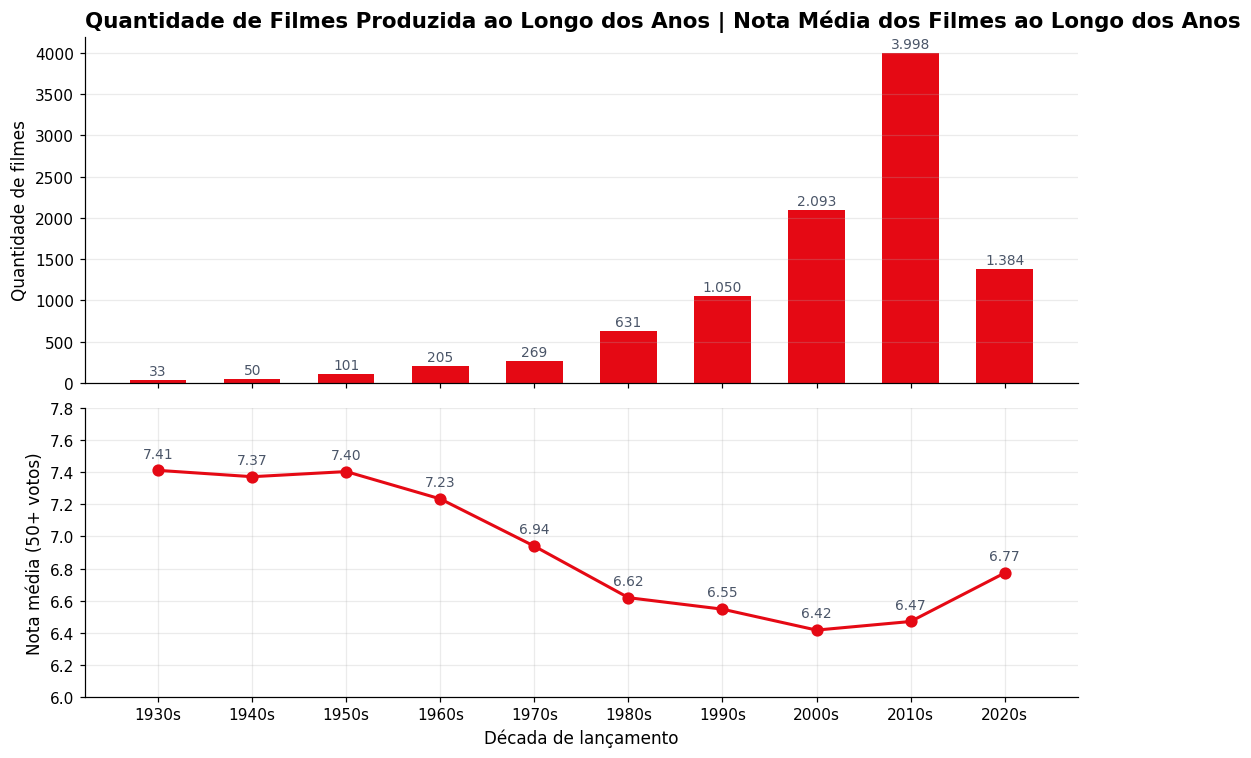

In [15]:
g6 = filmes[filmes["decada"] >= 1930].groupby("decada").agg(qtd=("titulo", "count"))
g6["nota"] = conf[conf["decada"] >= 1930].groupby("decada")["nota_media"].mean()
rotulos = [f"{d}s" for d in g6.index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                               gridspec_kw={"height_ratios": [1.2, 1]})
ax1.bar(rotulos, g6["qtd"], color=COR_FILME, width=0.6)
for i, v in enumerate(g6["qtd"]):
    ax1.text(i, v + 60, f"{v:,}".replace(",", "."), ha="center", color=COR_NEUTRA, fontsize=9)
ax1.set_ylabel("Quantidade de filmes")
ax1.set_title("Quantidade de Filmes Produzida ao Longo dos Anos | Nota Média dos Filmes ao Longo dos Anos")
ax1.grid(axis="x", visible=False)

ax2.plot(rotulos, g6["nota"], color=COR_FILME, marker="o", markersize=7, linewidth=2)
for i, v in enumerate(g6["nota"]):
    ax2.text(i, v + 0.08, f"{v:.2f}", ha="center", color=COR_NEUTRA, fontsize=9)
ax2.set_ylabel("Nota média (50+ votos)")
ax2.set_xlabel("Década de lançamento")
ax2.set_ylim(6, 7.8)
fig.tight_layout()
salvar(fig, "06_filmes_por_decada")
plt.show()
#Quanto mais recente a década, mais filmes e menor a nota

**Conclusão:** a quantidade de filmes cresce década a década (3.998 nos anos 2010), enquanto a nota média cai de 7,4 nos anos 30 a 50 para 6,4 nos anos 2000. Isso indica um viés de sobrevivência: dos filmes antigos, só os clássicos continuam populares. Os dois painéis evitam um gráfico com dois eixos verticais.

## 7. Filmes com mais votos têm notas mais altas? (seaborn)

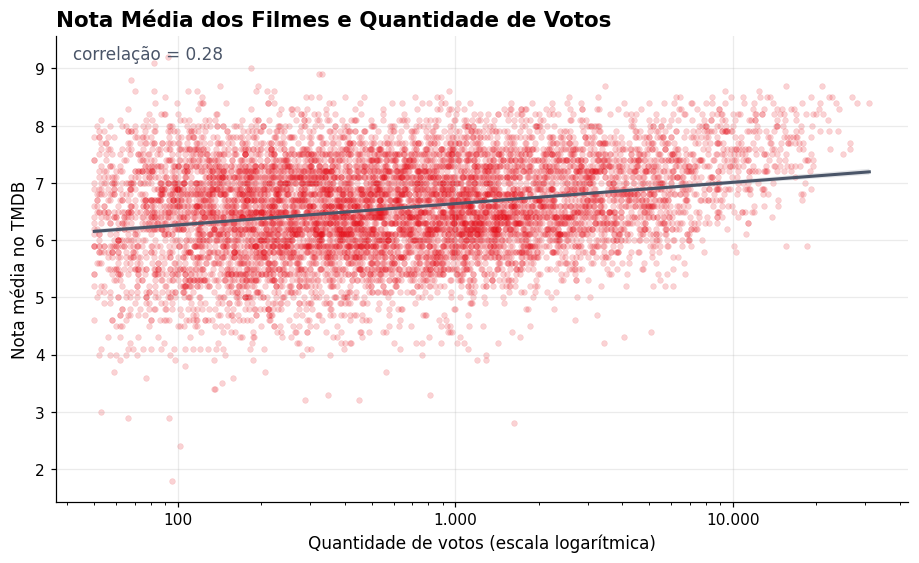

In [16]:
r = np.corrcoef(conf["qtd_votos"], conf["nota_media"])[0, 1]

fig, ax = plt.subplots()
sns.scatterplot(data=conf, x="qtd_votos", y="nota_media", color=COR_FILME, alpha=0.18,
                s=14, edgecolor=None, ax=ax)
sns.regplot(data=conf, x="qtd_votos", y="nota_media", logx=True, scatter=False,
            color=COR_NEUTRA, line_kws={"linewidth": 2}, ax=ax)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
ax.text(0.02, 0.95, f"correlação = {r:.2f}", transform=ax.transAxes, color=COR_NEUTRA, fontsize=11)
ax.set_title("Nota Média dos Filmes e Quantidade de Votos")
ax.set_xlabel("Quantidade de votos (escala logarítmica)")
ax.set_ylabel("Nota média no TMDB")
salvar(fig, "07_votos_x_nota")
plt.show()

**Conclusão:** a tendência é positiva, mas fraca (correlação de 0,28). Os 25% de filmes mais votados têm nota média de 6,89, contra 6,37 dos 25% menos votados. Há muitos filmes com nota alta e poucos votos, por isso os votos sozinhos não preveem a nota.

## 8. Quais idiomas originais aparecem mais e como são avaliados?

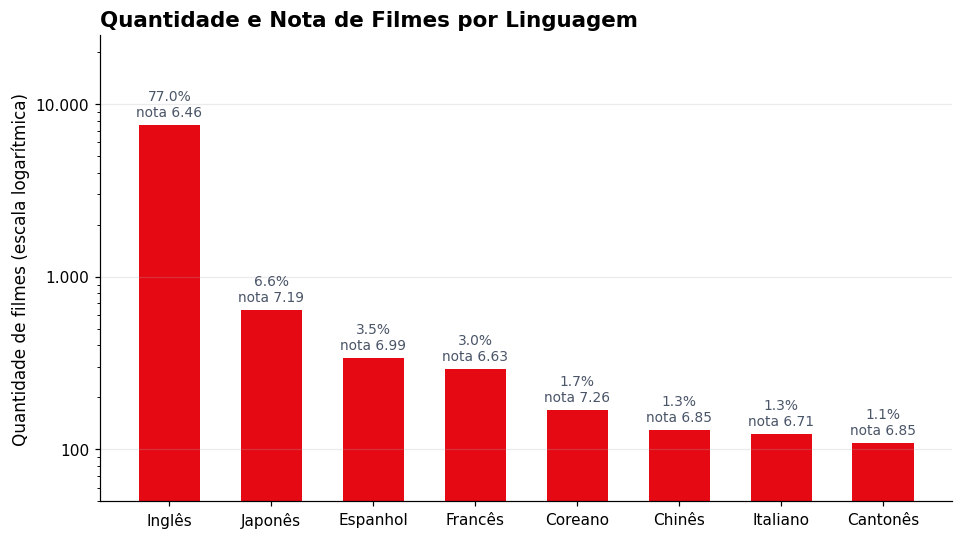

In [20]:
g8 = filmes.groupby("idioma").agg(qtd=("titulo", "count")).sort_values("qtd", ascending=False).head(8)
g8["nota"] = conf.groupby("idioma")["nota_media"].mean()
g8["pct"] = 100 * g8["qtd"] / len(filmes)

fig, ax = plt.subplots()
ax.bar(g8.index, g8["qtd"], color=COR_FILME, width=0.6)
ax.set_yscale("log")
for i, (q, p, n) in enumerate(zip(g8["qtd"], g8["pct"], g8["nota"])):
    ax.text(i, q * 1.12, f"{p:.1f}%\nnota {n:.2f}", ha="center", color=COR_NEUTRA, fontsize=9)
ax.set_ylim(50, 25000)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
ax.set_title("Quantidade e Nota de Filmes por Linguagem")
ax.set_ylabel("Quantidade de filmes (escala logarítmica)")
ax.grid(axis="x", visible=False)
salvar(fig, "08_idiomas_originais")
plt.show()

**Conclusão:** 77% dos filmes são em inglês, mas eles têm a menor nota média entre os principais idiomas (6,46). Coreano (7,26) e japonês (7,19) lideram. A escala logarítmica permite ver os idiomas menores ao lado do inglês.

## Lançamentos por ano nos dois temas

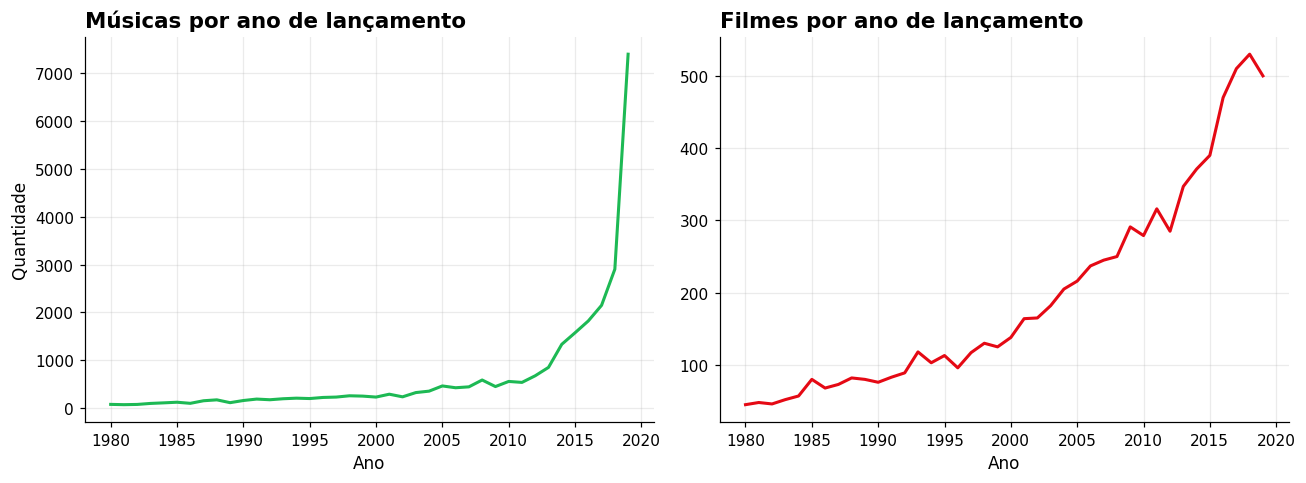

In [21]:
b = por_ano[por_ano["ano"].between(1980, 2019)]   # 2020 está incompleto no dataset de músicas

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
ax1.plot(b["ano"], b["qtd_musicas"], color=COR_MUSICA, linewidth=2)
ax1.set_title("Músicas por ano de lançamento")
ax1.set_ylabel("Quantidade")
ax2.plot(b["ano"], b["qtd_filmes"], color=COR_FILME, linewidth=2)
ax2.set_title("Filmes por ano de lançamento")
for ax in (ax1, ax2):
    ax.set_xlabel("Ano")

fig.tight_layout()
salvar(fig, "09_bonus_lancamentos_por_ano")
plt.show()

**Conclusão:** os dois temas crescem ao longo do tempo, o que explica a correlação de 0,70 entre eles. O motivo é a forma como os dados foram coletados (playlists e filmes populares hoje), e não uma relação entre música e cinema.